# ChemWorld 共享世界挑战：Leaderboard 与项目设计

本 notebook 把 12 天教程转化为研究型课堂项目和轻量 leaderboard 方案。核心规则很简单：每条赛道都是同一个 ChemWorld 物理化学世界规律下的不同 task slice。


## 学习路径定位

| 项目 | 内容 |
| --- | --- |
| 阶段 | E. 项目组织 |
| 难度 | 课程/项目设计 |
| 先修 | 已经理解 submission bundle、local eval machine 和 leaderboard 指标。 |
| 今天只解决 | 设计本机教师端/学生端评测组织方式，明确如何提交、验证和排名。 |
| 今天不要求 | 不搭云端账号系统，也不把 leaderboard 变成唯一评分标准。 |
| 本日交付 | 评测机目录结构、榜单指标、项目 track、提交协议。 |
| 下一步如何复用 | 可直接作为课程项目说明或实验室内部 challenge 草案。 |



## 课堂时间盒：每 30 分钟都有产出

建议按 3 小时工作坊使用。每一段都要留下一个小证据，不要只运行代码看到结果就继续往下翻。

| 时间 | 阶段目标 | 具体动作 | 当段产出 |
| --- | --- | --- | --- |
| 0:00-0:30 | 确定课程赛道 | 选择 reaction、purification、generalization 或 tool-agent 赛道。 | 得到赛道清单。 |
| 0:30-1:00 | 定义评分指标 | 设置 performance、safety、efficiency、explanation 权重。 | 得到 rubric 表。 |
| 1:00-1:30 | 设计提交包 | 明确 manifest、trajectory、results、explanation。 | 得到 submission spec。 |
| 1:30-2:00 | 组织教师端 | 规划 inbox、validate、verify、evaluate、leaderboard 流程。 | 得到评测机流程图。 |
| 2:00-2:30 | 组织学生端 | 设计 sandbox、public task cards、schema 和示例。 | 得到学生端工作说明。 |
| 2:30-3:00 | 发布项目说明 | 把赛道、时间线、评分和诚信规则写成项目 brief。 | 得到可发给学生的项目说明。 |

教师提示：如果课堂时间少于 3 小时，可以把最后两个时间盒改成课后提交；但前四个时间盒建议现场完成。


## 本日任务梯度

| 层级 | 任务 |
| --- | --- |
| 基础任务 | 画出教师端、学生端和 shared specs 的文件流。 |
| 进阶任务 | 设计 performance、sample efficiency、safety、explanation 多榜。 |
| 挑战任务 | 写出防止重复劳动和过拟合刷榜的项目管理规则。 |
| 反思问题 | 怎样让 leaderboard 鼓励科学探索，而不只是鼓励刷最高分？ |



## 三小时实验工单（必须自己完成）

这一节不是演示输出，而是当天真正的工作量。请不要只从上到下运行已有单元；必须在后面的学生工作区新增自己的实验、图表、表格和文字结论。

| 序号 | 最小完成量 |
| --- | --- |
| 1 | 模拟至少 2 个学生提交、2 个 task、2 个 seed 的本机评测流程。 |
| 2 | 输出教师端 inbox、验证日志、结果表、leaderboard 四类文件结构。 |
| 3 | 设计至少 4 个榜：performance、sample efficiency、safety、explanation。 |
| 4 | 写出双人/小组协作规则：如何声明任务、如何提交、如何避免重复劳动和刷榜。 |

验收口径：本日交付至少应包含数据表、图或谱图、验证/评测结果、机制解释和下一步实验建议。低于这些证据量，视为只完成了演示浏览。



## 学生工作区

请从这里开始写自己的实验扩展。建议保留上方演示单元作为参考，不要直接覆盖；把你新增的实验条件、图、模型、验证结果和文字结论放在下面。

建议你在本节下面新增自己的代码单元。可从这个记录模板开始：

```python
student_work = {
    "hypothesis": "",
    "experiments_added": 0,
    "figures_created": 0,
    "verification_or_metric": "",
    "next_experiment": "",
}
```



In [1]:
import importlib
import sys
from pathlib import Path

import pandas as pd
from IPython.display import display

ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists() and ROOT.parent != ROOT:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "notebooks" / "tutorials"))

import chemworld  # noqa: E402,F401
from chemworld.tasks import list_task_cards  # noqa: E402

tu = importlib.import_module("tutorial_utils")
pd.set_option("display.precision", 4)
print("project root:", ROOT)


project root: D:\Projects\ChemWorld


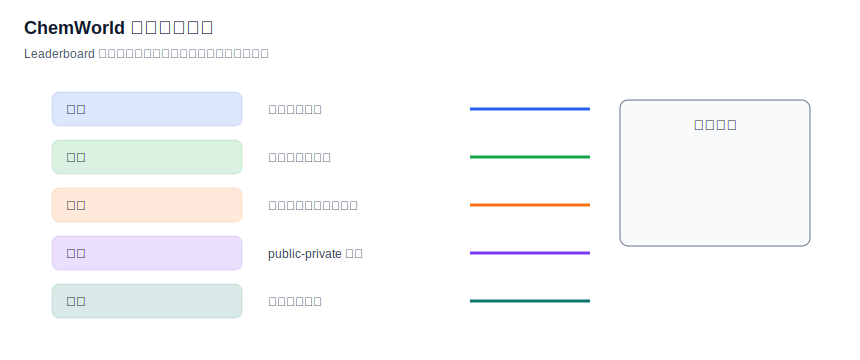

In [2]:
tu.display_project_canvas(
    title="ChemWorld 共享世界挑战",
    problem="谁能在有限实验预算下学习有用的局部 world model，并做出安全闭环决策？",
    strategy="在同一个 world law 的 task slices 上比较学生、GPT 辅助 planner、BO、safe BO 和混合系统。",
    artifact="包含 trajectories、manifest、results、explanations 和 replay verification 的提交包。",
    risks="单一公开分数可能诱导过拟合、不安全探索和浅层解释。",
)
display(tu.leaderboard_blueprint_svg())


## 1. 任务面板

项目不应该让每个小组发明一个新 simulator。每个团队应从共享 task registry 中选择一到两个任务卡。


In [3]:
cards = list_task_cards()
task_board = pd.DataFrame(
    [
        {
            "task_id": card["task_id"],
            "difficulty": card["difficulty"],
            "budget": card["budget"],
            "operations": ", ".join(card["allowed_operations"][:5])
            + ("..." if len(card["allowed_operations"]) > 5 else ""),
            "metrics": ", ".join(
                card["reward_leaderboard_metric"]["success_metrics"]
            ),
            "recommended_use": ", ".join(card["recommended_use"]),
        }
        for card in cards
    ]
)
task_board


,task_id,difficulty,budget,operations,metrics,recommended_use
0,low-budget-characterization,hard,18,"add_reagent, add_solvent, add_catalyst, heat, ...","sample_efficiency, uncertainty, local_model_qu...","BO, RL, benchmark"
1,partition-discovery,standard,48,"add_solvent, add_reagent, add_phase, add_extra...","phase_ratio, product_in_organic, product_in_aq...",benchmark
2,public-private-generalization,standard,72,"add_reagent, add_solvent, add_catalyst, heat, ...","score, public_private_gap, rank_confidence",benchmark
3,purity-yield-tradeoff,standard,90,"add_reagent, add_solvent, add_catalyst, heat, ...","yield, purity, recovery, cost",benchmark
4,reaction-mechanism-explanation,standard,36,"add_reagent, add_solvent, add_catalyst, heat, ...","score, mechanism_explanation, failure_analysis","LLM-agent, benchmark"
5,reaction-optimization-standard,standard,72,"add_reagent, add_solvent, add_catalyst, heat, ...","score, yield, selectivity, sample_efficiency","BO, RL, benchmark"
6,reaction-safety-constrained,standard,72,"add_reagent, add_solvent, add_catalyst, heat, ...","score, safety_risk, constraint_violations",benchmark
7,reaction-to-assay,smoke,18,"add_reagent, add_solvent, add_catalyst, heat, ...","final_assay_score, trajectory_validity","benchmark, teaching"
8,reaction-to-purification,standard,90,"add_reagent, add_solvent, add_catalyst, heat, ...","score, purity, recovery, process_mass_balance_...",benchmark
9,tool-agent-planning,standard,48,"add_reagent, add_solvent, add_catalyst, heat, ...","trajectory_validity, validator_use, score, exp...","LLM-agent, benchmark"


## 2. Leaderboard 设计

请使用多个榜单。最终课程成绩或研究排名可以报告综合分，但公开 leaderboard 应保留性能、安全、效率、泛化和解释之间的权衡。


In [4]:
leaderboard_schema = pd.DataFrame(
    [
        {
            "board": "Performance",
            "weight": 0.30,
            "metric": "private final-assay score",
            "failure mode prevented": "only optimizing public-test",
        },
        {
            "board": "Safety",
            "weight": 0.20,
            "metric": "low risk and few violations",
            "failure mode prevented": "unsafe high-yield recipes",
        },
        {
            "board": "Sample efficiency",
            "weight": 0.20,
            "metric": "area-under-best-score / budget",
            "failure mode prevented": "brute-force search",
        },
        {
            "board": "Generalization",
            "weight": 0.15,
            "metric": "small public-private gap",
            "failure mode prevented": "overfitting public worlds",
        },
        {
            "board": "Scientific understanding",
            "weight": 0.15,
            "metric": "mechanism explanation rubric",
            "failure mode prevented": "black-box score chasing",
        },
    ]
)
leaderboard_schema


,board,weight,metric,failure mode prevented
0,Performance,0.30,private final-assay score,only optimizing public-test
1,Safety,0.20,low risk and few violations,unsafe high-yield recipes
2,Sample efficiency,0.20,area-under-best-score / budget,brute-force search
3,Generalization,0.15,small public-private gap,overfitting public worlds
4,Scientific understanding,0.15,mechanism explanation rubric,black-box score chasing


## 3. 推荐项目赛道

每个团队选择一个主赛道和一个辅助诊断。这样既能保持项目可比较，也能留下足够创造空间。


In [5]:
project_tracks = pd.DataFrame(
    [
        {
            "track": "Reaction optimizer",
            "primary task": "reaction-optimization-standard",
            "core question": "Can you beat scripted chemistry without becoming unsafe?",
        },
        {
            "track": "Safety-first agent",
            "primary task": "reaction-safety-constrained",
            "core question": "How much score is worth giving up for robust low risk?",
        },
        {
            "track": "Purification strategist",
            "primary task": "reaction-to-purification",
            "core question": (
                "Can downstream processing recover purity without destroying yield?"
            ),
        },
        {
            "track": "Partition scientist",
            "primary task": "partition-discovery",
            "core question": "Can a learner infer phase behavior from sparse measurements?",
        },
        {
            "track": "Tool-using LLM planner",
            "primary task": "tool-agent-planning",
            "core question": "Can language proposals survive validator checks and replay?",
        },
    ]
)
project_tracks


,track,primary task,core question
0,Reaction optimizer,reaction-optimization-standard,Can you beat scripted chemistry without becomi...
1,Safety-first agent,reaction-safety-constrained,How much score is worth giving up for robust l...
2,Purification strategist,reaction-to-purification,Can downstream processing recover purity witho...
3,Partition scientist,partition-discovery,Can a learner infer phase behavior from sparse...
4,Tool-using LLM planner,tool-agent-planning,Can language proposals survive validator check...


## 4. 提交包

只有能够回放的结果才应该进入 leaderboard。每个团队都提交相同结构的 bundle。


In [6]:
submission_bundle = {
    "manifest.json": [
        "agent_name",
        "agent_family",
        "task_id",
        "seeds",
        "command_used",
        "commit_hash",
    ],
    "trajectories/": ["one JSONL per task/seed/split"],
    "results/": ["evaluation JSON generated by chemworld evaluate or suite"],
    "explanations/": [
        "hypothesis, learned mechanism, failure analysis, next experiment rationale"
    ],
    "README.md": ["what was tried, what failed, what should be trusted"],
}
tu.show_json_panel("Required submission bundle", submission_bundle)


## 5. 示例可见榜单

下面的数字只是 mock rows，用来展示榜单形状，不是官方 benchmark 结果。


In [7]:
mock_board = pd.DataFrame(
    [
        {
            "team": "scripted-reference",
            "performance": 0.61,
            "safety": 0.82,
            "efficiency": 0.55,
            "generalization": 0.74,
            "understanding": 0.68,
        },
        {
            "team": "bo-optimizer",
            "performance": 0.67,
            "safety": 0.58,
            "efficiency": 0.73,
            "generalization": 0.62,
            "understanding": 0.52,
        },
        {
            "team": "safe-bo",
            "performance": 0.63,
            "safety": 0.88,
            "efficiency": 0.64,
            "generalization": 0.69,
            "understanding": 0.56,
        },
        {
            "team": "human-gpt-hybrid",
            "performance": 0.65,
            "safety": 0.76,
            "efficiency": 0.66,
            "generalization": 0.71,
            "understanding": 0.81,
        },
    ]
)
weights = leaderboard_schema.set_index("board")["weight"].to_dict()
mock_board["composite"] = (
    mock_board["performance"] * weights["Performance"]
    + mock_board["safety"] * weights["Safety"]
    + mock_board["efficiency"] * weights["Sample efficiency"]
    + mock_board["generalization"] * weights["Generalization"]
    + mock_board["understanding"] * weights["Scientific understanding"]
)
mock_board.sort_values("composite", ascending=False)


,team,performance,safety,efficiency,generalization,understanding,composite
3,human-gpt-hybrid,0.65,0.76,0.66,0.71,0.81,0.7070
2,safe-bo,0.63,0.88,0.64,0.69,0.56,0.6805
0,scripted-reference,0.61,0.82,0.55,0.74,0.68,0.6700
1,bo-optimizer,0.67,0.58,0.73,0.62,0.52,0.6340


In [8]:
tu.display_reflection_box(
    [
        '开发阶段哪些榜单应公开，哪些应保留到最终评测？',
        '什么证据能说明 agent 学到了化学规律，而不是利用了评分漏洞？',
        '每个项目 README 至少必须包含哪些内容，结果才应被 leaderboard 接收？',
    ]
)
